In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Step 1: Import Libraries

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

Step 2: Set Dataset Path

In [8]:
train_dir = '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Testing'
test_dir = '/content/drive/MyDrive/CN7023(Artificial Intelligence)/archive/Training'
IMAGE_SIZE = 128

Step 3: Load Dataset

In [9]:
def load_data(directory):
    paths, labels = [], []
    for label in os.listdir(directory):
        for img in os.listdir(os.path.join(directory, label)):
            paths.append(os.path.join(directory, label, img))
            labels.append(label)
    return paths, labels

train_paths, train_labels = load_data(train_dir)
test_paths, test_labels = load_data(test_dir)

Step 4: Encode Labels

In [10]:
classes = sorted(os.listdir(train_dir))

def encode(labels):
    return np.array([classes.index(l) for l in labels])

Step 5: Preprocess Images

In [11]:
def process(paths):
    data = []
    for p in paths:
        img = load_img(p, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        img = img_to_array(img) / 255.0
        data.append(img)
    return np.array(data)

X_train = process(train_paths)
y_train = encode(train_labels)

X_test = process(test_paths)
y_test = encode(test_labels)

Step 6: Build Baseline CNN Model

In [12]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(classes), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Step 7: Compile Model

In [13]:
model.compile(optimizer=Adam(0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Step 8: Train Model

In [14]:
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=32,
                    validation_split=0.2)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.4430 - loss: 1.2125 - val_accuracy: 0.0000e+00 - val_loss: 2.7408
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.5547 - loss: 1.0332 - val_accuracy: 0.0000e+00 - val_loss: 2.1149
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.6109 - loss: 0.8907 - val_accuracy: 0.0969 - val_loss: 1.9744
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.6742 - loss: 0.7651 - val_accuracy: 0.4000 - val_loss: 1.4590
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.7188 - loss: 0.6805 - val_accuracy: 0.6375 - val_loss: 1.0916


Step 9: Plot Accuracy & Loss

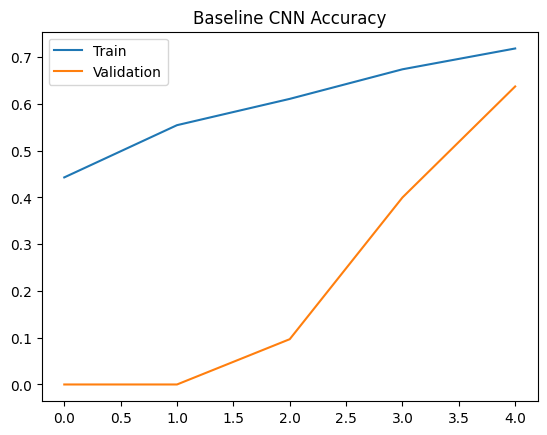

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Baseline CNN Accuracy")
plt.legend(["Train","Validation"])
plt.show()

Step 10: Predictions

In [16]:
pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1)

175/175 ━━━━━━━━━━━━━━━━━━━━ 47s 269ms/step


Step 11: Classification Report

In [17]:
print(classification_report(y_test, pred_classes))

              precision    recall  f1-score   support

           0       0.49      0.77      0.60      1400
           1       0.52      0.50      0.51      1400
           2       0.99      0.48      0.65      1400
           3       0.79      0.76      0.77      1400

    accuracy                           0.63      5600
   macro avg       0.70      0.63      0.63      5600
weighted avg       0.70      0.63      0.63      5600



Accuracy & Loss Over Epochs

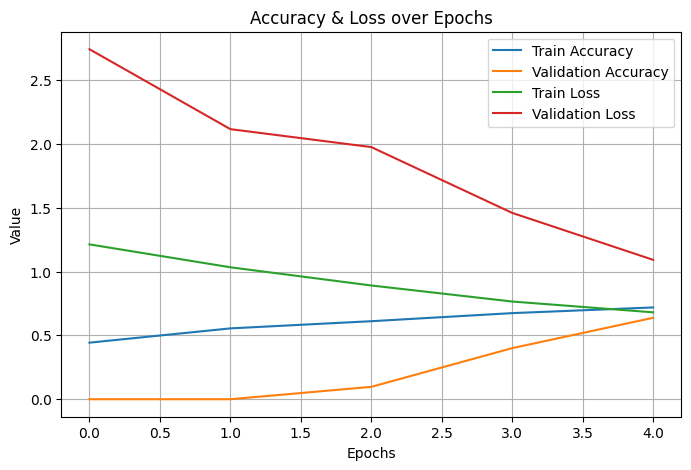

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Accuracy & Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()

Step 12: Confusion Matrix

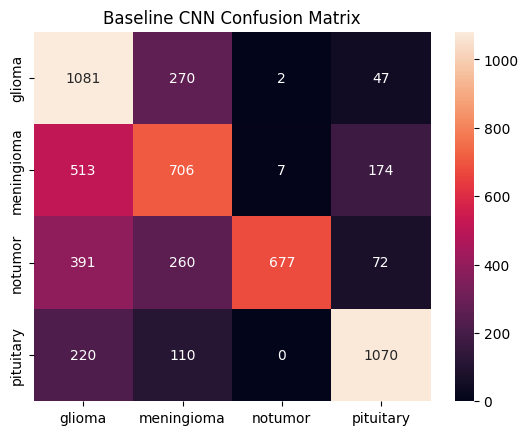

In [19]:
cm = confusion_matrix(y_test, pred_classes)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.title("Baseline CNN Confusion Matrix")
plt.show()

In [22]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Accuracy
acc = accuracy_score(y_test, pred_classes)

# F1 Score (choose type based on your problem)
f1 = f1_score(y_test, pred_classes, average='weighted')
# use 'macro' if classes are balanced

print("Accuracy:", acc)
print("F1 Score:", f1)

# Optional (very useful for report)
print("\nClassification Report:\n")
print(classification_report(y_test, pred_classes, target_names=classes))

Accuracy: 0.6310714285714286
F1 Score: 0.6343836746185108

Classification Report:

              precision    recall  f1-score   support

      glioma       0.49      0.77      0.60      1400
  meningioma       0.52      0.50      0.51      1400
     notumor       0.99      0.48      0.65      1400
   pituitary       0.79      0.76      0.77      1400

    accuracy                           0.63      5600
   macro avg       0.70      0.63      0.63      5600
weighted avg       0.70      0.63      0.63      5600



Final Model Test Accuracy Visualization

175/175 ━━━━━━━━━━━━━━━━━━━━ 51s 293ms/step - accuracy: 0.6311 - loss: 0.9365


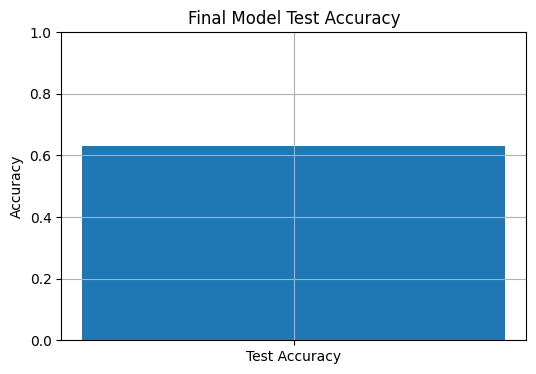

Test Accuracy: 0.6310714483261108


In [20]:
test_loss, test_acc = model.evaluate(X_test, y_test)

plt.figure(figsize=(6,4))
plt.bar(["Test Accuracy"], [test_acc])
plt.ylim(0, 1)
plt.title("Final Model Test Accuracy")
plt.ylabel("Accuracy")
plt.grid()

plt.show()

print("Test Accuracy:", test_acc)

Step 13: ROC Curve

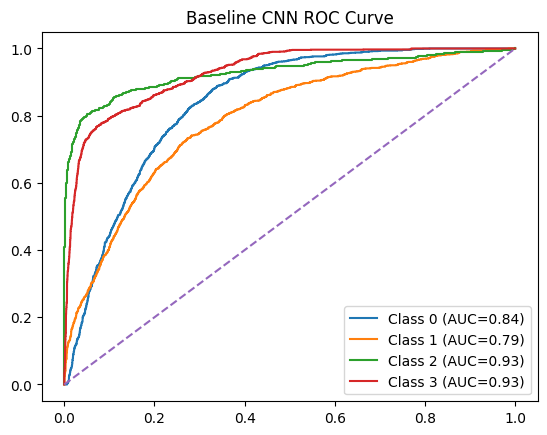

In [21]:
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))

plt.figure()
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("Baseline CNN ROC Curve")
plt.show()